# Data Preparation for Cat vs Dog Classification

This notebook inspects the image dataset stored in the `PetImages` folder and prepares a structured summary for model training.

## 1. Import Libraries

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf


## 2. Set Random Seed

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


## 3. Verify Dataset Folder

In [3]:
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
pet_images_dir = project_root / 'PetImages'

def verify_dataset_folder(folder_path: Path) -> bool:
    """Check whether the dataset folder exists."""
    if folder_path.exists() and folder_path.is_dir():
        print(f"Dataset folder found: {folder_path}")
        return True
    else:
        print(f"Dataset folder not found: {folder_path}")
        return False

dataset_exists = verify_dataset_folder(pet_images_dir)

Dataset folder found: c:\Users\taikh\OneDrive\Documents\JSI Checkpoint 1\CatDogClassifier\PetImages


## 4. Count Images by Class

In [4]:
def count_images(folder_path: Path) -> dict:
    """Count image files in each class folder."""
    counts = {}
    for class_name in ['Cat', 'Dog']:
        class_dir = folder_path / class_name
        if class_dir.exists():
            image_files = [f for f in class_dir.iterdir() if f.is_file() and f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff'}]
            counts[class_name] = len(image_files)
        else:
            counts[class_name] = 0
    return counts

if dataset_exists:
    image_counts = count_images(pet_images_dir)
    cat_count = image_counts['Cat']
    dog_count = image_counts['Dog']
    total_images = cat_count + dog_count

    print(f"Number of Cat images: {cat_count}")
    print(f"Number of Dog images: {dog_count}")
    print(f"Total images: {total_images}")

Number of Cat images: 12497
Number of Dog images: 12494
Total images: 24991


## 5. Build a DataFrame with Image Metadata

In [5]:
def build_dataframe(folder_path: Path) -> pd.DataFrame:
    """Create a dataframe containing image metadata."""
    records = []
    for class_name in ['Cat', 'Dog']:
        class_dir = folder_path / class_name
        if not class_dir.exists():
            continue

        for image_path in class_dir.iterdir():
            if image_path.is_file() and image_path.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff'}:
                records.append({
                    'filepath': str(image_path),
                    'label': class_name.lower(),
                    'filename': image_path.stem,
                    'extension': image_path.suffix.lower()
                })

    df = pd.DataFrame(records)
    return df

if dataset_exists:
    df = build_dataframe(pet_images_dir)
    display(df.head(10))

,filepath,label,filename,extension
0,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,0,.jpg
1,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,1,.jpg
2,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10,.jpg
3,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,100,.jpg
4,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,1000,.jpg
5,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10000,.jpg
6,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10001,.jpg
7,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10002,.jpg
8,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10003,.jpg
9,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10004,.jpg


## 6. Explore the DataFrame

In [6]:
if dataset_exists:
    print("\nFirst 10 rows:")
    display(df.head(10))

    print("\nDataFrame information:")
    df.info()

    print("\nDataFrame statistics:")
    display(df.describe(include='all'))


First 10 rows:


,filepath,label,filename,extension
0,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,0,.jpg
1,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,1,.jpg
2,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10,.jpg
3,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,100,.jpg
4,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,1000,.jpg
5,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10000,.jpg
6,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10001,.jpg
7,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10002,.jpg
8,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10003,.jpg
9,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10004,.jpg



DataFrame information:
<class 'pandas.DataFrame'>
RangeIndex: 24991 entries, 0 to 24990
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   filepath   24991 non-null  str  
 1   label      24991 non-null  str  
 2   filename   24991 non-null  str  
 3   extension  24991 non-null  str  
dtypes: str(4)
memory usage: 3.2 MB

DataFrame statistics:


,filepath,label,filename,extension
count,24991,24991,24991,24991
unique,24991,2,12500,1
top,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,0,.jpg
freq,1,12497,2,24991


## 7. Visualize Class Distribution

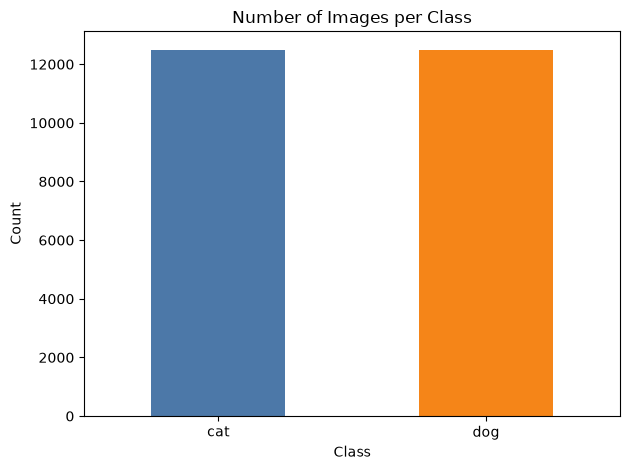

In [7]:
def plot_class_distribution(df: pd.DataFrame):
    """Plot a bar chart showing the number of images per class."""
    class_counts = df['label'].value_counts().reindex(['cat', 'dog']).fillna(0)
    class_counts.plot(kind='bar', color=['#4C78A8', '#F58518'])
    plt.title('Number of Images per Class')
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

if dataset_exists:
    plot_class_distribution(df)

## 8. Display Random Sample Images

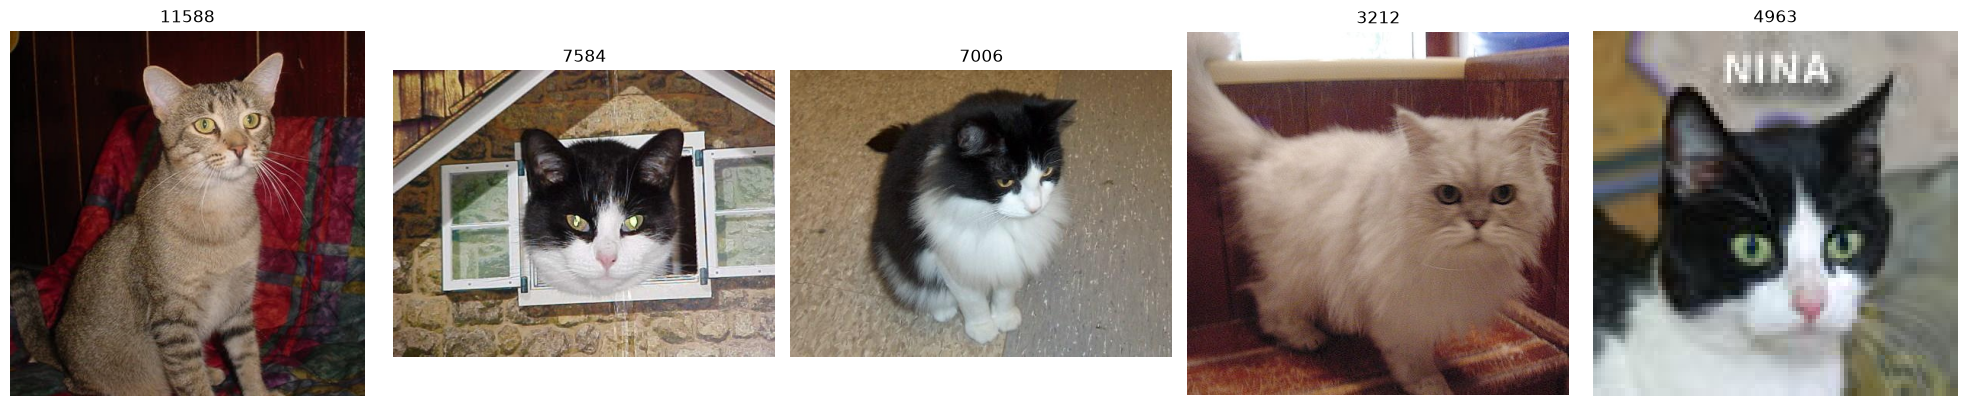

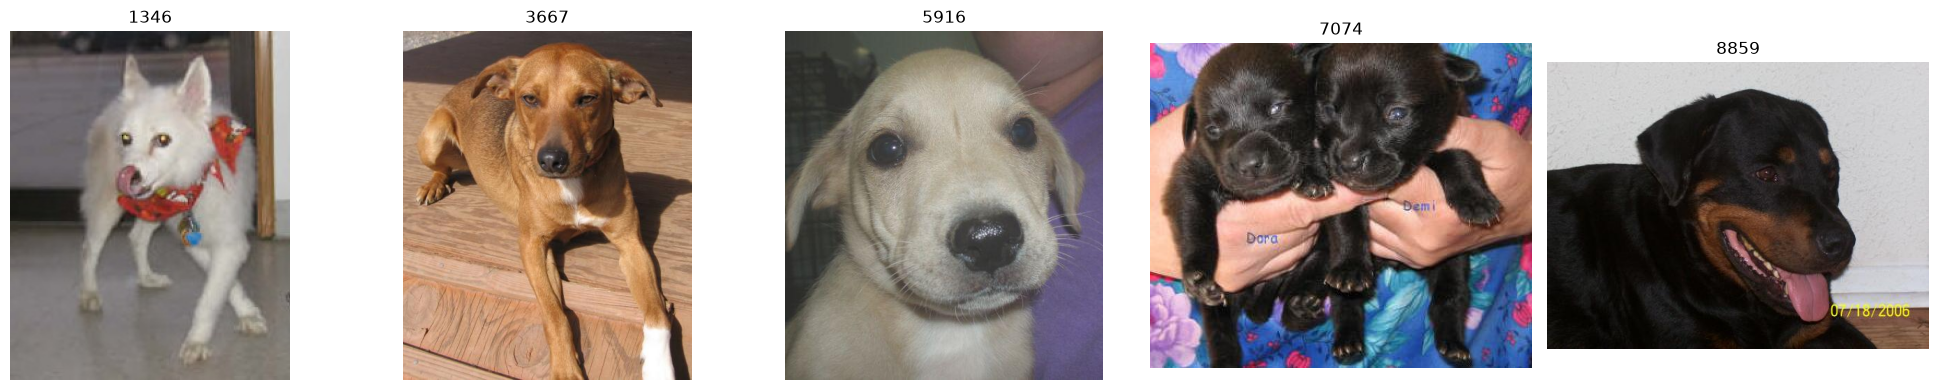

In [8]:
def display_sample_images(df: pd.DataFrame, label: str, n: int = 5):
    """Display a random sample of images for a given class."""
    sample_df = df[df['label'] == label.lower()].sample(n=n, random_state=RANDOM_SEED)
    fig, axes = plt.subplots(1, n, figsize=(20, 4))
    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        image = Image.open(row['filepath'])
        ax.imshow(image)
        ax.axis('off')
        ax.set_title(row['filename'])
    plt.tight_layout()
    plt.show()

if dataset_exists:
    display_sample_images(df, 'cat', 5)
    display_sample_images(df, 'dog', 5)

## 9. Print Image Dimensions

In [9]:
def print_random_dimensions(df: pd.DataFrame, n: int = 10):
    """Print dimensions for several random images."""
    sample_df = df.sample(n=min(n, len(df)), random_state=RANDOM_SEED)
    for _, row in sample_df.iterrows():
        with Image.open(row['filepath']) as img:
            width, height = img.size
            print(f"{row['filename']} -> width={width}, height={height}")

if dataset_exists:
    print_random_dimensions(df, 10)

299 -> width=329, height=500
10569 -> width=500, height=375
6559 -> width=443, height=500
6834 -> width=450, height=378
3738 -> width=500, height=436
476 -> width=381, height=373
8748 -> width=294, height=360
12147 -> width=440, height=293
8568 -> width=500, height=375
12059 -> width=309, height=232


## 10. Calculate Image Size Statistics

In [10]:
def calculate_image_dimensions(df: pd.DataFrame) -> dict:
    """Calculate minimum, maximum, and average image widths and heights."""
    widths = []
    heights = []

    for _, row in df.iterrows():
        with Image.open(row['filepath']) as img:
            width, height = img.size
            widths.append(width)
            heights.append(height)

    return {
        'min_width': int(np.min(widths)),
        'max_width': int(np.max(widths)),
        'min_height': int(np.min(heights)),
        'max_height': int(np.max(heights)),
        'avg_width': round(float(np.mean(widths)), 2),
        'avg_height': round(float(np.mean(heights)), 2)
    }

if dataset_exists:
    stats = calculate_image_dimensions(df)
    print("\nImage size statistics:")
    for key, value in stats.items():
        print(f"{key}: {value}")

c:\Users\taikh\AppData\Local\Programs\Python\Python312\Lib\site-packages\PIL\TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Image size statistics:
min_width: 4
max_width: 500
min_height: 4
max_height: 500
avg_width: 404.47
avg_height: 361.02


## 11. Final Notes

In [11]:
if dataset_exists:
    print("\nDataset inspection complete. The dataframe is ready for preprocessing and model training.")



Dataset inspection complete. The dataframe is ready for preprocessing and model training.


## 12. TensorFlow Dataset Preparation

This stage converts the cleaned image folders into TensorFlow datasets. The images will be resized to a consistent shape, batched, and prepared for training, validation, and testing. This workflow is designed to be compatible with future data augmentation and transfer learning steps.


## 13. Create TensorFlow Datasets

The next cells build three separate datasets without overlap by using the directory-based loading utilities in a controlled way. This ensures the model is evaluated on data that has not been seen during training.


## 13. Create TensorFlow Datasets

The next cells build three separate datasets without overlap by using the directory-based loading utilities in a controlled way. This ensures the model is evaluated on data that has not been seen during training.

### Preprocessing steps
- Images are loaded directly from the PetImages directory.
- Each image is resized to 224x224 pixels for a consistent input shape.
- Images are grouped into batches of 32 for efficient training.
- The data is split into training, validation, and test subsets with no overlap.
- The datasets are cached and prefetched to improve performance during model training.


In [12]:
def clean_dataset(folder_path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Validate images, remove corrupted files, and return summary information."""
    records = []
    error_records = []

    for class_name in ['Cat', 'Dog']:
        class_dir = folder_path / class_name
        if not class_dir.exists():
            continue

        for image_path in class_dir.iterdir():
            if not image_path.is_file() or image_path.suffix.lower() not in {'.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tif', '.tiff'}:
                continue

            try:
                with Image.open(image_path) as img:
                    img.verify()
                records.append({
                    'filepath': str(image_path),
                    'label': class_name.lower(),
                    'error': None
                })
            except Exception as exc:
                error_records.append({
                    'filepath': str(image_path),
                    'label': class_name.lower(),
                    'error': str(exc)
                })
                try:
                    image_path.unlink()
                    print(f"Removed corrupted image: {image_path}")
                except OSError as remove_error:
                    print(f"Could not remove {image_path}: {remove_error}")

    cleaned_summary_df = pd.DataFrame(error_records)
    return cleaned_summary_df, pd.DataFrame(records)


def rebuild_clean_dataframe(folder_path: Path) -> pd.DataFrame:
    """Rebuild the dataframe from the cleaned image folders."""
    return build_dataframe(folder_path)


if dataset_exists:
    cleaning_summary_df, cleaned_image_df = clean_dataset(pet_images_dir)

    print(f"Number of corrupted images removed: {len(cleaning_summary_df)}")
    print(f"Number of remaining Cat images: {len(cleaned_image_df[cleaned_image_df['label'] == 'cat'])}")
    print(f"Number of remaining Dog images: {len(cleaned_image_df[cleaned_image_df['label'] == 'dog'])}")
    print(f"Total remaining images: {len(cleaned_image_df)}")

    print("\nCleaning summary dataframe:")
    display(cleaning_summary_df.head(10))

    cleaned_df = rebuild_clean_dataframe(pet_images_dir)
    cleaned_df.to_csv(project_root / 'clean_dataset.csv', index=False)

    print(f"\nCleaned dataframe saved to: {project_root / 'clean_dataset.csv'}")
    print("\nRebuilt dataframe preview:")
    display(cleaned_df.head(10))


Number of corrupted images removed: 0
Number of remaining Cat images: 12497
Number of remaining Dog images: 12494
Total remaining images: 24991

Cleaning summary dataframe:


""



Cleaned dataframe saved to: c:\Users\taikh\OneDrive\Documents\JSI Checkpoint 1\CatDogClassifier\clean_dataset.csv

Rebuilt dataframe preview:


,filepath,label,filename,extension
0,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,0,.jpg
1,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,1,.jpg
2,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10,.jpg
3,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,100,.jpg
4,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,1000,.jpg
5,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10000,.jpg
6,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10001,.jpg
7,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10002,.jpg
8,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10003,.jpg
9,c:\Users\taikh\OneDrive\Documents\JSI Checkpoi...,cat,10004,.jpg


Found 24991 files belonging to 2 classes.
Using 17494 files for training.
Found 24991 files belonging to 2 classes.
Using 7497 files for validation.
Training images: 17504
Validation images: 3744
Testing images: 3776
Number of training batches: 547
Class names: ['Cat', 'Dog']

Training batch preview:


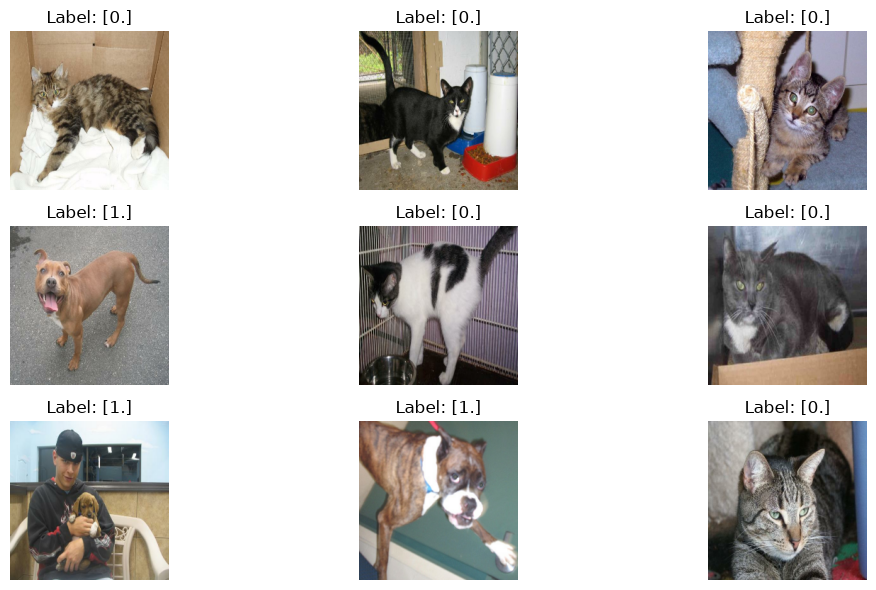

Image tensor shape: (32, 224, 224, 3)
Label tensor shape: (32, 1)

The TensorFlow datasets are ready for augmentation and transfer learning.


In [13]:
import tensorflow as tf

# Image configuration for TensorFlow datasets
image_size = (224, 224)
batch_size = 32
seed = RANDOM_SEED
label_mode = 'binary'

AUTOTUNE = tf.data.AUTOTUNE

# This helper creates a directory-based TensorFlow dataset with a fixed split.
def build_tensorflow_datasets(data_dir: Path, image_size: tuple, batch_size: int, seed: int):
    """Create train, validation, and test datasets from the image folders."""
    train_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode=label_mode,
        image_size=image_size,
        batch_size=batch_size,
        validation_split=0.30,
        subset='training',
        seed=seed,
        interpolation='bilinear'
    )

    remaining_ds = tf.keras.utils.image_dataset_from_directory(
        data_dir,
        labels='inferred',
        label_mode=label_mode,
        image_size=image_size,
        batch_size=batch_size,
        validation_split=0.30,
        subset='validation',
        seed=seed,
        interpolation='bilinear'
    )

    # Split the remaining 30% into validation and test sets without overlap.
    total_batches = tf.data.experimental.cardinality(remaining_ds).numpy()
    val_batches = total_batches // 2
    test_batches = total_batches - val_batches

    val_ds = remaining_ds.take(val_batches)
    test_ds = remaining_ds.skip(val_batches)

    return train_ds, val_ds, test_ds


if dataset_exists:
    train_ds, val_ds, test_ds = build_tensorflow_datasets(pet_images_dir, image_size, batch_size, seed)
    class_names = train_ds.class_names

    train_count = tf.data.experimental.cardinality(train_ds).numpy() * batch_size
    val_count = tf.data.experimental.cardinality(val_ds).numpy() * batch_size
    test_count = tf.data.experimental.cardinality(test_ds).numpy() * batch_size

    print(f"Training images: {train_count}")
    print(f"Validation images: {val_count}")
    print(f"Testing images: {test_count}")
    print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
    print(f"Class names: {class_names}")

# Cache and prefetch datasets for better performance.
def prepare_dataset(dataset):
    """Cache and prefetch a dataset for faster training."""
    dataset = dataset.cache()
    dataset = dataset.prefetch(buffer_size=AUTOTUNE)
    return dataset


if dataset_exists:
    train_ds = prepare_dataset(train_ds)
    val_ds = prepare_dataset(val_ds)
    test_ds = prepare_dataset(test_ds)

# Preview one batch from the training dataset.
if dataset_exists:
    for images, labels in train_ds.take(1):
        print("\nTraining batch preview:")
        plt.figure(figsize=(12, 6))
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            label_value = labels[i].numpy()
            if hasattr(label_value, "shape") and label_value.shape == ():
                label_text = int(label_value)
            else:
                label_text = label_value
            plt.title(f"Label: {label_text}")
            plt.axis("off")
        plt.tight_layout()
        plt.show()

        print(f"Image tensor shape: {images.shape}")
        print(f"Label tensor shape: {labels.shape}")

# The datasets are now ready for augmentation and transfer learning.
if dataset_exists:
    print("\nThe TensorFlow datasets are ready for augmentation and transfer learning.")
